In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,f1_score

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
#Naming the columns
columns=['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level']


In [4]:
#Loading Dataset
train_path=r"../data/KDDTrain+.txt"
train_df=pd.read_csv(train_path,delimiter=",")

test_path=r"../data/KDDTest+.txt"
test_df=pd.read_csv(test_path,delimiter=",")

In [5]:
train_df.columns=columns
test_df.columns=columns

In [6]:
train_df.drop(['level'],axis=1,inplace=True)
test_df.drop(['level'],axis=1,inplace=True)

In [7]:
# No of rows
print("NO OF Train ROWS:")
print(len(train_df))

print("NO OF Test ROWS:")
print(len(test_df))

NO OF Train ROWS:
125972
NO OF Test ROWS:
22543


In [8]:
print(train_df.shape)
print(test_df.shape)

(125972, 42)
(22543, 42)


In [9]:
#No of Unique Labels
print('NO OF UNIQUE LABELS:')
labels=train_df.iloc[:,-1]
print(labels.unique())
# or train_df['outcome'].unique()

NO OF UNIQUE LABELS:
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [10]:
print(test_df.iloc[:,-1].unique())

['neptune' 'normal' 'saint' 'mscan' 'guess_passwd' 'smurf' 'apache2'
 'satan' 'buffer_overflow' 'back' 'warezmaster' 'snmpgetattack'
 'processtable' 'pod' 'httptunnel' 'nmap' 'ps' 'snmpguess' 'ipsweep'
 'mailbomb' 'portsweep' 'multihop' 'named' 'sendmail' 'loadmodule' 'xterm'
 'worm' 'teardrop' 'rootkit' 'xlock' 'perl' 'land' 'xsnoop' 'sqlattack'
 'ftp_write' 'imap' 'udpstorm' 'phf']


In [11]:
# Drop classes in test_df which are not in train_df
classes_to_drop = test_df[~test_df['outcome'].isin(train_df['outcome'])]['outcome'].unique()
test_df = test_df[~test_df['outcome'].isin(classes_to_drop)]
print(test_df.iloc[:,-1].unique())

['neptune' 'normal' 'guess_passwd' 'smurf' 'satan' 'buffer_overflow'
 'back' 'warezmaster' 'pod' 'nmap' 'ipsweep' 'portsweep' 'multihop'
 'loadmodule' 'teardrop' 'rootkit' 'perl' 'land' 'ftp_write' 'imap' 'phf']


In [12]:
# Drop classes in train_df which are not in test_df
classes_to_drop = train_df[~train_df['outcome'].isin(test_df['outcome'])]['outcome'].unique()
train_df = train_df[~train_df['outcome'].isin(classes_to_drop)]
print(train_df.iloc[:,-1].unique())

['normal' 'neptune' 'ipsweep' 'portsweep' 'teardrop' 'nmap' 'satan'
 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop' 'rootkit'
 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land' 'loadmodule' 'perl']


In [13]:
# equal classes in outcome label
print(train_df['outcome'].value_counts())
print(test_df['outcome'].value_counts())

outcome
normal             67342
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
Name: count, dtype: int64
outcome
normal             9711
neptune            4656
guess_passwd       1231
warezmaster         944
satan               735
smurf               665
back                359
portsweep           157
ipsweep             141
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
rootkit              13
teardrop             12
land                  7
ftp_write             3
perl                  2
l

In [14]:
#Top 5 freq attack type
print('Top 5 Frequent attack types:')
print(labels.value_counts().head(5))

Top 5 Frequent attack types:
outcome
normal       67342
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
Name: count, dtype: int64


In [15]:
# groups very rare classes into an OTHER class

# Step 1: Count class frequencies
class_counts = train_df['outcome'].value_counts()
# Step 2: Define threshold (e.g., classes with <20 samples → OTHER)
threshold = 21
rare_classes = class_counts[class_counts < threshold].index.tolist()
print("Rare classes grouped into OTHER:", rare_classes)
# Step 3: Map rare classes to OTHER
train_df['outcome'] = train_df['outcome'].apply(lambda x: 'OTHER' if x in rare_classes else x)
# Step 4: Check new distribution
print(train_df['outcome'].value_counts())


# group for test_df['outcome']
class_counts = test_df['outcome'].value_counts()
# Step 2: Define threshold (e.g., classes with <20 samples → OTHER)
threshold = 20
rare_classes = class_counts[class_counts < threshold].index.tolist()
print("Rare classes grouped into OTHER:", rare_classes)
# Step 3: Map rare classes to OTHER
test_df['outcome'] = test_df['outcome'].apply(lambda x: 'OTHER' if x in rare_classes else x)
print(test_df['outcome'].value_counts())

Rare classes grouped into OTHER: ['warezmaster', 'land', 'imap', 'rootkit', 'loadmodule', 'ftp_write', 'multihop', 'phf', 'perl']
outcome
normal             67342
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
pod                  201
OTHER                 90
guess_passwd          53
buffer_overflow       30
Name: count, dtype: int64
Rare classes grouped into OTHER: ['multihop', 'rootkit', 'teardrop', 'land', 'ftp_write', 'perl', 'loadmodule', 'phf', 'imap']
outcome
normal             9711
neptune            4656
guess_passwd       1231
warezmaster         944
satan               735
smurf               665
back                359
portsweep           157
ipsweep             141
nmap                 73
OTHER                60
pod                  41
buffer_overflow      20
Name: count, dtype: int64


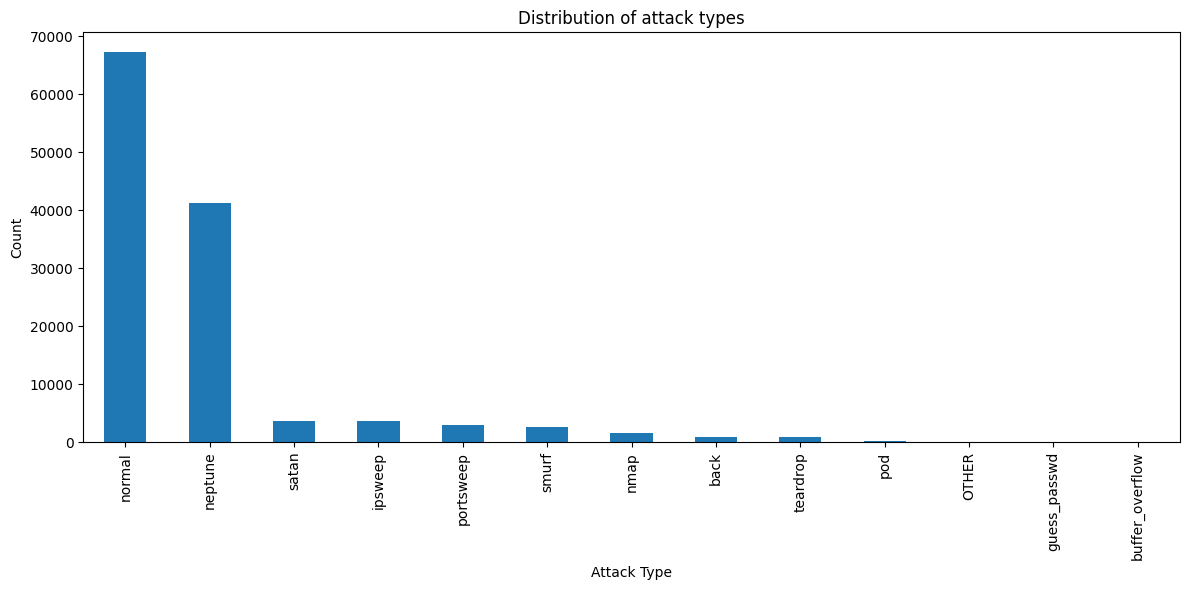

In [16]:
#Bar chart showing distribution of attack types.
label_count=train_df['outcome'].value_counts()
plt.figure(figsize=(12,6))
label_count.plot(kind='bar')
plt.title('Distribution of attack types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

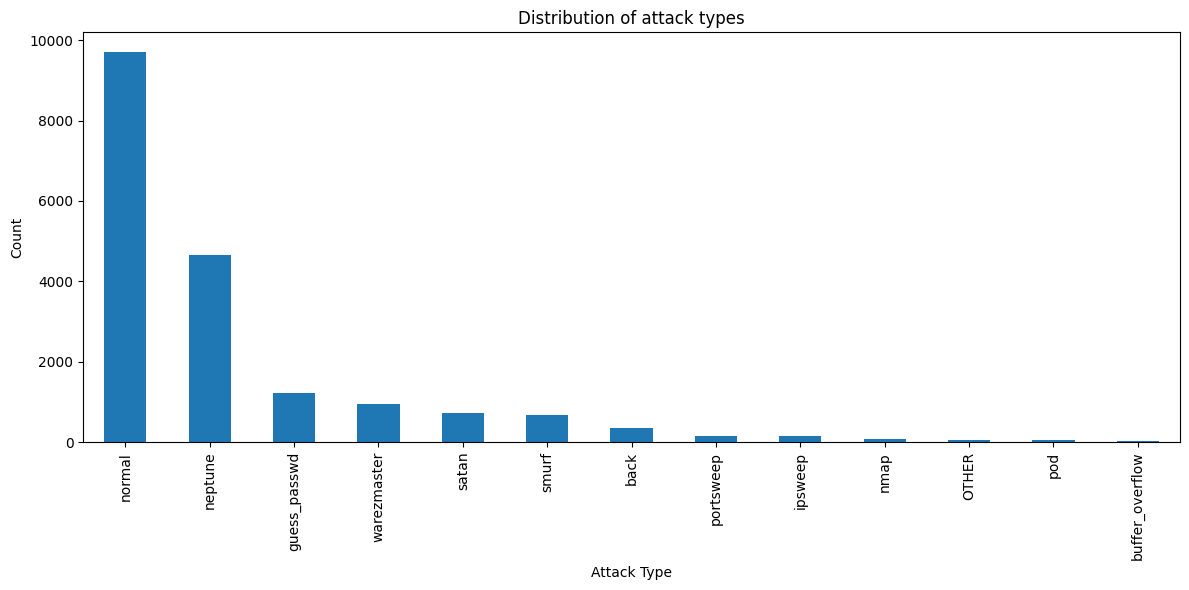

In [17]:
#Bar chart showing distribution of attack types.
label_count=test_df.iloc[:,-1].value_counts()
plt.figure(figsize=(12,6))
label_count.plot(kind='bar')
plt.title('Distribution of attack types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [18]:
#Basic inspection
print('First 5 rows of train data:')
train_df.head()

First 5 rows of train data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal
1,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune
2,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal
3,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal
4,0,tcp,private,REJ,0,0,0,0,0,0,...,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune


In [19]:
print('First 5 rows of test data:')
test_df.head()

First 5 rows of test data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal
4,0,tcp,http,SF,267,14515,0,0,0,0,...,255,1.00,0.00,0.01,0.03,0.01,0.00,0.00,0.00,normal
5,0,tcp,smtp,SF,1022,387,0,0,0,0,...,28,0.11,0.72,0.00,0.00,0.00,0.00,0.72,0.04,normal
6,0,tcp,telnet,SF,129,174,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.01,0.01,0.02,0.02,guess_passwd


In [20]:
print('Last 5 rows of train data:')
train_df.tail()

Last 5 rows of train data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
125967,0,tcp,private,S0,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune
125968,8,udp,private,SF,105,145,0,0,0,0,...,244,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,30,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune
125971,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,77,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal


In [21]:
print('Last 5 rows of test data:')
test_df.tail()

Last 5 rows of test data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
22537,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.00,0.0,0.00,0.00,smurf
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,141,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal
22539,0,tcp,http,SF,317,938,0,0,0,0,...,255,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,255,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,252,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal


In [22]:
print('Structure of dataset')
train_df.info()

Structure of dataset
<class 'pandas.core.frame.DataFrame'>
Index: 125080 entries, 0 to 125971
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125080 non-null  int64  
 1   protocol_type                125080 non-null  object 
 2   service                      125080 non-null  object 
 3   flag                         125080 non-null  object 
 4   src_bytes                    125080 non-null  int64  
 5   dst_bytes                    125080 non-null  int64  
 6   land                         125080 non-null  int64  
 7   wrong_fragment               125080 non-null  int64  
 8   urgent                       125080 non-null  int64  
 9   hot                          125080 non-null  int64  
 10  num_failed_logins            125080 non-null  int64  
 11  logged_in                    125080 non-null  int64  
 12  num_compromised              125080 non-nu

In [23]:
print('Statistical summary')
train_df.describe()

Statistical summary


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125080.000000,1.250800e+05,1.250800e+05,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000,...,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000,125080.000000
mean,284.172570,4.344425e+04,1.991446e+04,0.000200,0.022849,0.000112,0.140454,0.001231,0.391437,0.281244,...,182.770987,116.163264,0.519950,0.083391,0.145031,0.032108,0.286391,0.280440,0.119648,0.121094
std,2606.035637,5.890207e+06,4.035598e+06,0.014136,0.254426,0.014417,1.706984,0.045400,0.488074,24.027346,...,98.814252,110.896372,0.449218,0.189467,0.304943,0.112513,0.445751,0.446643,0.307492,0.320437
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.680000e+02,5.110000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
#Feature types
print('Feature types:')
print(train_df.dtypes)

Feature types:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror

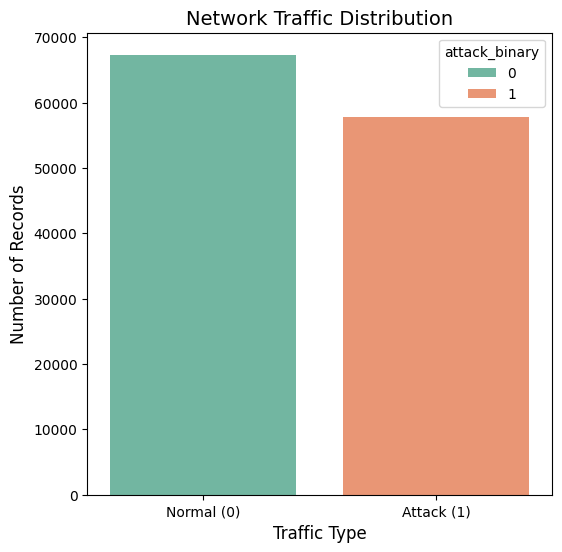

Class Distribution (%):
 attack_binary
0    53.839143
1    46.160857
Name: proportion, dtype: float64
attack_binary
0    67342
1    57738
Name: count, dtype: int64


In [25]:
# Create binary target for both train and test sets
train_df['attack_binary'] = train_df['outcome'].apply(lambda x: 0 if x.lower() == 'normal' else 1)
test_df['attack_binary'] = test_df['outcome'].apply(lambda x: 0 if x.lower() == 'normal' else 1)

# Plot class distribution (with labels)
plt.figure(figsize=(6, 6))
sns.countplot(x='attack_binary', hue='attack_binary', data=train_df, palette='Set2')
plt.title('Network Traffic Distribution', fontsize=14)
plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks([0, 1], ['Normal (0)', 'Attack (1)'])
plt.show()

# Show exact percentages
class_dist = train_df['attack_binary'].value_counts(normalize=True) * 100
print("Class Distribution (%):\n", class_dist)

print(train_df['attack_binary'].value_counts())

In [26]:
#Identify categorical vs. numerical features
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_features = train_df.select_dtypes(exclude=['object']).columns.tolist()
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['protocol_type', 'service', 'flag', 'outcome']
Numerical Features: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_binary']


In [27]:
#Identify categorical vs. numerical features
categorical_features = test_df.select_dtypes(include=['object']).columns.tolist()
numerical_features = test_df.select_dtypes(exclude=['object']).columns.tolist()
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['protocol_type', 'service', 'flag', 'outcome']
Numerical Features: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_binary']


In [28]:
#Checking for missing values and duplicates
#Missing values
print("Missing values per column:")
print(train_df.isnull().sum())
print("Missing values per column:")
print(test_df.isnull().sum())

Missing values per column:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate   

In [29]:
#For duplicates
num_duplicates = train_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
num_duplicates = test_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0
Number of duplicate rows: 0


In [30]:
#Create a schema mapping table
binary = {"land","logged_in","root_shell","su_attempted","is_host_login","is_guest_login"}
drop = {"num_outbound_cmds","is_host_login","level"}
special = {"src_bytes":"Log-transform + Normalize","dst_bytes":"Log-transform + Normalize"}
labels = {"outcome":"Label encode","category":"Label encode"}
def infer_type(col, s):
    if col in binary: return "Binary"
    if s.dtype=="object": return "Categorical"
    return "Numerical"
def preprocessing(col, t):
    if col in drop: return "Drop"
    if col in special: return special[col]
    if col in labels: return labels[col]
    if t=="Binary": return "Keep as is (0/1)"
    if t=="Categorical": return "One-hot encode / Label encode"
    if t=="Numerical": return "Already normalized" if "_rate" in col else "Normalize/Standardize"
    return "Check"
schema = [{"Feature":c,
           "Type":infer_type(c,train_df[c]),
           "Preprocessing":preprocessing(c,infer_type(c,train_df[c])),
           "Semantic":"Label" if c in ["outcome","category"] else "Feature"}
          for c in train_df.columns]
schema_df = pd.DataFrame(schema)
display(schema_df)

,Feature,Type,Preprocessing,Semantic
0,duration,Numerical,Normalize/Standardize,Feature
1,protocol_type,Categorical,One-hot encode / Label encode,Feature
2,service,Categorical,One-hot encode / Label encode,Feature
3,flag,Categorical,One-hot encode / Label encode,Feature
4,src_bytes,Numerical,Log-transform + Normalize,Feature
5,dst_bytes,Numerical,Log-transform + Normalize,Feature
6,land,Binary,Keep as is (0/1),Feature
7,wrong_fragment,Numerical,Normalize/Standardize,Feature
8,urgent,Numerical,Normalize/Standardize,Feature
9,hot,Numerical,Normalize/Standardize,Feature


In [31]:
#Identify and handle missing values in NSL-KDD dataset
for col in train_df.columns:
    if train_df[col].isnull().sum() > 0:
        if train_df[col].dtype == 'object':
            train_df[col].fillna(train_df[col].mode()[0], inplace=True)
        else:
            train_df[col].fillna(train_df[col].median(), inplace=True)
print("Missing values handled.")
for col in test_df.columns:
    if test_df[col].isnull().sum() > 0:
        if test_df[col].dtype == 'object':
            test_df[col].fillna(test_df[col].mode()[0], inplace=True)
        else:
            test_df[col].fillna(test_df[col].median(), inplace=True)
print("Missing values handled.")

Missing values handled.
Missing values handled.


In [32]:
#Remove Duplicate Rows
train_df = train_df.drop_duplicates()
print("Duplicates removed. Current shape:", train_df.shape)
test_df = test_df.drop_duplicates()
print("Duplicates removed. Current shape:", test_df.shape)

Duplicates removed. Current shape: (125080, 43)
Duplicates removed. Current shape: (18793, 43)


Binary Classification

In [33]:
#Label Encoding
# Columns to encode
categorical_cols = ['protocol_type', 'service', 'flag']

# Apply label encoding
for col in categorical_cols:
    le = LabelEncoder()

    # Fit on train, transform both train & test
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

print("Train shape after Label Encoding:", train_df.shape)
print("Test shape after Label Encoding:", test_df.shape)
print(train_df[categorical_cols].head())

Train shape after Label Encoding: (125080, 43)
Test shape after Label Encoding: (18793, 43)
   protocol_type  service  flag
0              2       44     9
1              1       49     5
2              1       24     9
3              1       24     9
4              1       49     1


In [34]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 125080 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125080 non-null  int64  
 1   protocol_type                125080 non-null  int64  
 2   service                      125080 non-null  int64  
 3   flag                         125080 non-null  int64  
 4   src_bytes                    125080 non-null  int64  
 5   dst_bytes                    125080 non-null  int64  
 6   land                         125080 non-null  int64  
 7   wrong_fragment               125080 non-null  int64  
 8   urgent                       125080 non-null  int64  
 9   hot                          125080 non-null  int64  
 10  num_failed_logins            125080 non-null  int64  
 11  logged_in                    125080 non-null  int64  
 12  num_compromised              125080 non-null  int64  
 13  root

In [35]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 18793 entries, 0 to 22541
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     18793 non-null  int64  
 1   protocol_type                18793 non-null  int64  
 2   service                      18793 non-null  int64  
 3   flag                         18793 non-null  int64  
 4   src_bytes                    18793 non-null  int64  
 5   dst_bytes                    18793 non-null  int64  
 6   land                         18793 non-null  int64  
 7   wrong_fragment               18793 non-null  int64  
 8   urgent                       18793 non-null  int64  
 9   hot                          18793 non-null  int64  
 10  num_failed_logins            18793 non-null  int64  
 11  logged_in                    18793 non-null  int64  
 12  num_compromised              18793 non-null  int64  
 13  root_shell           

In [36]:
X_b_test = test_df.drop(columns=['outcome','attack_binary'])
y_b_test = test_df['attack_binary']

In [37]:
X_b=train_df.drop(columns=['outcome','attack_binary'])
y_b=train_df['attack_binary']

In [38]:
#  Train-Test-Split
X_b_train, X_bv_test, y_b_train, y_bv_test = train_test_split(X_b, y_b, test_size=0.3, random_state=42, stratify=y_b)
print("Training set shape:", X_b_train.shape)
print("Testing set shape:", X_bv_test.shape)

Training set shape: (87556, 41)
Testing set shape: (37524, 41)


In [39]:
# SMOTETomek (both undersample & oversample)
from imblearn.combine import SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_b_train, y_b_train= smote_tomek.fit_resample(X_b_train, y_b_train)

e:\SentinelNet\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\SentinelNet\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "e:\SentinelNet\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\siva\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~

In [40]:
# Implementing logistic regression using label encoding is misleads the model
scaler = StandardScaler()
X_b_train_scaled = scaler.fit_transform(X_b_train)
X_bv_test_scaled = scaler.transform(X_bv_test)
X_b_test_scaled = scaler.transform(X_b_test)

# # Implementing Logistic Regression
lr = LogisticRegression(max_iter=500, solver="lbfgs")
lr.fit(X_b_train_scaled, y_b_train)

#Training accuracy
y_b_pred_lr= lr.predict(X_b_train_scaled)
accuracy_lr=accuracy_score(y_b_train, y_b_pred_lr)
print(f"Logistic Regression Training Accuracy: {accuracy_lr* 100:.2f}%")

y_b_pred_lr= lr.predict(X_bv_test_scaled)
accuracy_lr=accuracy_score(y_bv_test, y_b_pred_lr)
print(f"Logistic Regression Validation Accuracy: {accuracy_lr* 100:.2f}%")
print(classification_report(y_bv_test, y_b_pred_lr))

y_b_pred_lr= lr.predict(X_b_test_scaled)
accuracy_lr_test=accuracy_score(y_b_test, y_b_pred_lr)
print(f"Logistic Regression Test Accuracy: {accuracy_lr_test * 100:.2f}%")
print(classification_report(y_b_test, y_b_pred_lr))

Logistic Regression Training Accuracy: 97.18%
Logistic Regression Validation Accuracy: 97.11%
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     20203
           1       0.97      0.97      0.97     17321

    accuracy                           0.97     37524
   macro avg       0.97      0.97      0.97     37524
weighted avg       0.97      0.97      0.97     37524

Logistic Regression Test Accuracy: 84.60%
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      9711
           1       0.91      0.75      0.83      9082

    accuracy                           0.85     18793
   macro avg       0.86      0.84      0.84     18793
weighted avg       0.86      0.85      0.84     18793



In [41]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200,random_state=42, class_weight="balanced")
rf.fit(X_b_train, y_b_train)

#Training accuracy
y_b_pred_rf = rf.predict(X_b_train)
accuracy_rf=accuracy_score(y_b_train, y_b_pred_rf)
print(f"Random Forest Training Accuracy: {accuracy_rf* 100:.2f}%")

y_b_pred_rf = rf.predict(X_bv_test)
accuracy_rf=accuracy_score(y_bv_test, y_b_pred_rf)
print(f"Random Forest Validation Accuracy: {accuracy_rf* 100:.2f}%")
print(classification_report(y_bv_test, y_b_pred_rf))

y_b_pred_rf = rf.predict(X_b_test)
accuracy_rf_test=accuracy_score(y_b_test, y_b_pred_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf_test * 100:.2f}%")
print(classification_report(y_b_test, y_b_pred_rf))

Random Forest Training Accuracy: 100.00%
Random Forest Validation Accuracy: 99.91%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       1.00      1.00      1.00     17321

    accuracy                           1.00     37524
   macro avg       1.00      1.00      1.00     37524
weighted avg       1.00      1.00      1.00     37524

Random Forest Test Accuracy: 86.62%
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      9711
           1       0.96      0.75      0.84      9082

    accuracy                           0.87     18793
   macro avg       0.88      0.86      0.86     18793
weighted avg       0.88      0.87      0.86     18793



In [42]:
# Decision Tree Classifier
dt_res = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=None)
dt_res.fit(X_b_train, y_b_train)

# Training accuracy
y_b_pred_dt = dt_res.predict(X_b_train)
accuracy_dt=accuracy_score(y_b_train, y_b_pred_dt)
print(f"Decision Tree Training Accuracy: {accuracy_dt* 100:.2f}%")

y_b_pred_dt = dt_res.predict(X_bv_test)
accuracy_dt=accuracy_score(y_bv_test, y_b_pred_dt)
print(f"Decision Tree Validation Accuracy: {accuracy_dt* 100:.2f}%")
print(classification_report(y_bv_test, y_b_pred_dt))

y_b_pred_dt = dt_res.predict(X_b_test)
accuracy_dt_test=accuracy_score(y_b_test, y_b_pred_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt_test * 100:.2f}%")
print(classification_report(y_b_test, y_b_pred_dt))

Decision Tree Training Accuracy: 100.00%
Decision Tree Validation Accuracy: 99.82%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       1.00      1.00      1.00     17321

    accuracy                           1.00     37524
   macro avg       1.00      1.00      1.00     37524
weighted avg       1.00      1.00      1.00     37524

Decision Tree Test Accuracy: 87.20%
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      9711
           1       0.96      0.77      0.85      9082

    accuracy                           0.87     18793
   macro avg       0.89      0.87      0.87     18793
weighted avg       0.89      0.87      0.87     18793



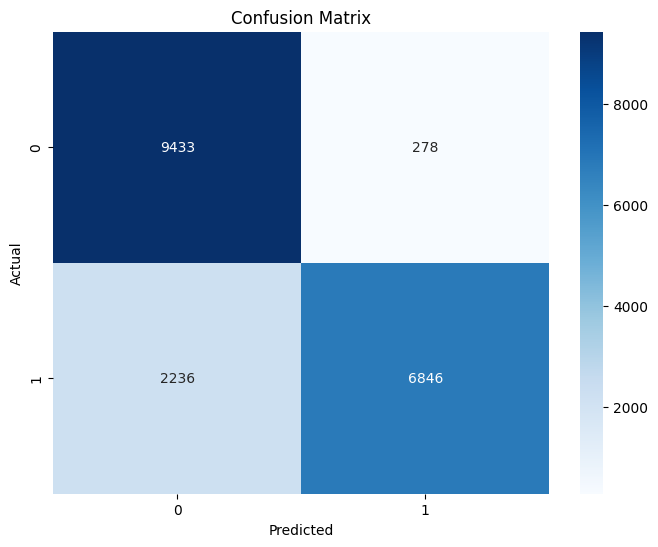

In [43]:
cm = confusion_matrix(y_b_test, y_b_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


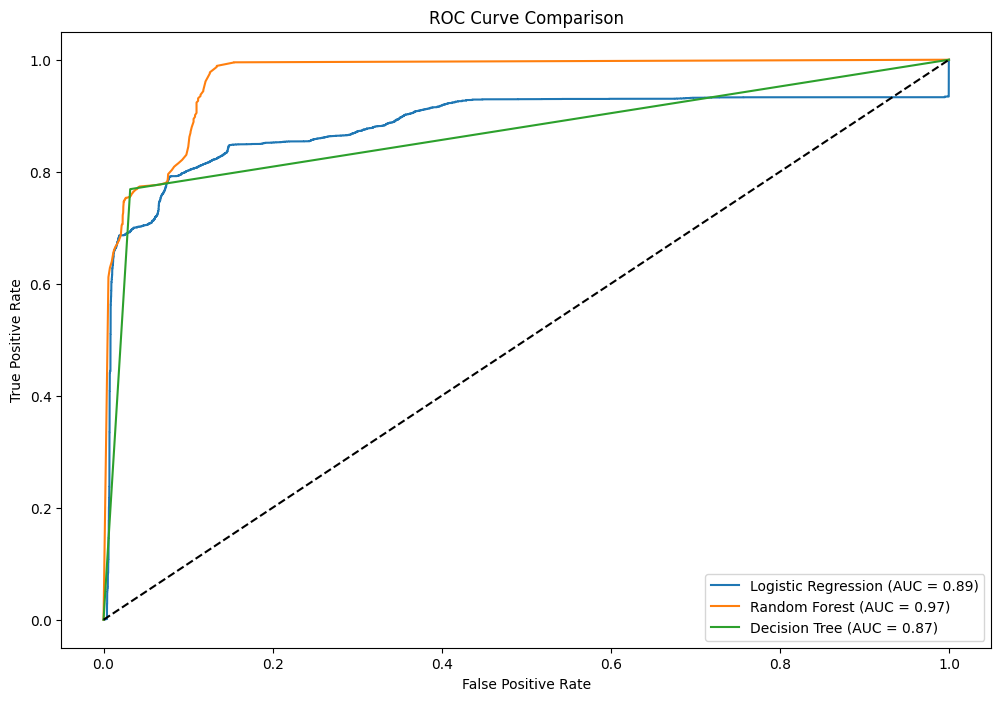

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# --- Logistic Regression ---
y_prob_lr = lr.predict_proba(X_b_test_scaled)[:, 1]   # probability for positive class

# --- Random Forest ---
y_prob_rf = rf.predict_proba(X_b_test)[:, 1]

# --- Decision Tree ---
y_prob_dt = dt_res.predict_proba(X_b_test)[:, 1]

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_b_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_b_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_dt, tpr_dt, _ = roc_curve(y_b_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plot ROC Curves
plt.figure(figsize=(12, 8))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()


C:\Users\siva\AppData\Local\Temp\ipykernel_6768\2695889378.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(model_scores, labels=model_names, patch_artist=True)


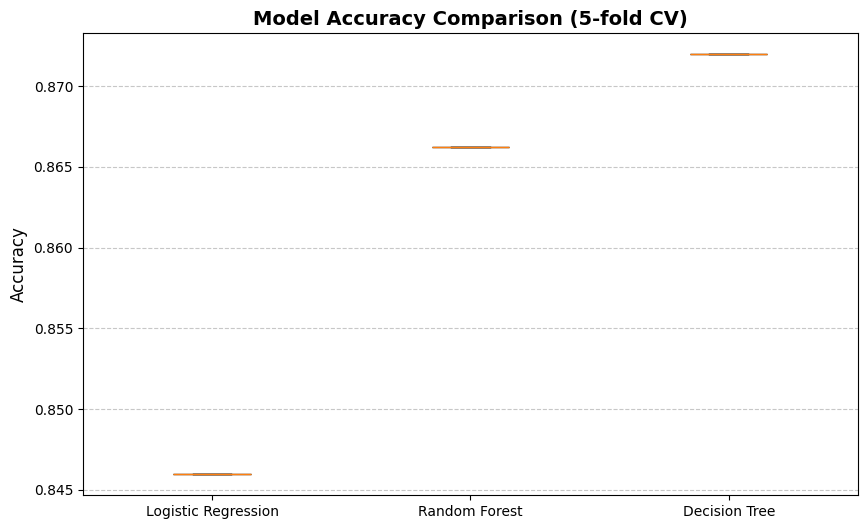

In [45]:
# box plot
model_scores = [
    [accuracy_lr_test],    # Logistic Regression accuracy
    [accuracy_rf_test],    # Random Forest accuracy
    [accuracy_dt_test]     # Decision Tree accuracy
]
model_names = ["Logistic Regression","Random Forest","Decision Tree"]
# show box plot
plt.figure(figsize=(10, 6))
plt.boxplot(model_scores, labels=model_names, patch_artist=True)
plt.title("Model Accuracy Comparison (5-fold CV)", fontsize=14, weight="bold")
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

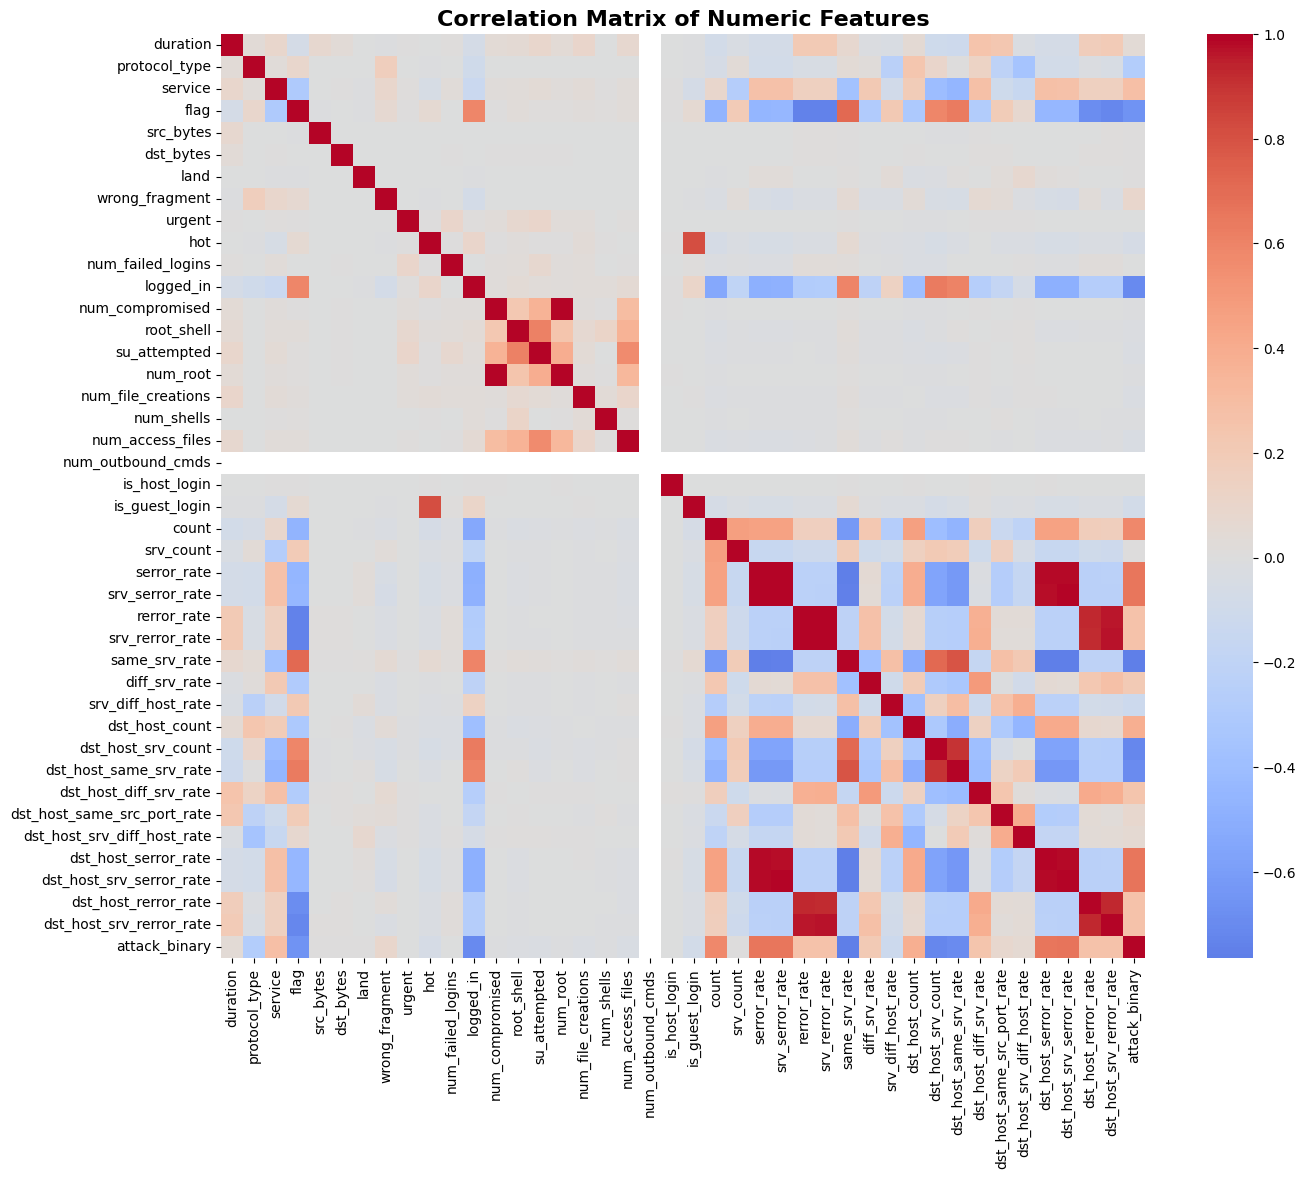

In [46]:
# Select only numeric columns
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = train_df[numeric_cols].corr()
# Plot
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=False,      # True = show correlation values
    cmap="coolwarm",
    center=0,
    cbar=True,
    square=True
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16, weight="bold")
plt.show()

Multiclass classification

In [47]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125080 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125080 non-null  int64  
 1   protocol_type                125080 non-null  int64  
 2   service                      125080 non-null  int64  
 3   flag                         125080 non-null  int64  
 4   src_bytes                    125080 non-null  int64  
 5   dst_bytes                    125080 non-null  int64  
 6   land                         125080 non-null  int64  
 7   wrong_fragment               125080 non-null  int64  
 8   urgent                       125080 non-null  int64  
 9   hot                          125080 non-null  int64  
 10  num_failed_logins            125080 non-null  int64  
 11  logged_in                    125080 non-null  int64  
 12  num_compromised              125080 non-null  int64  
 13  root

In [48]:
# Separate features and target
X = train_df.drop(columns=['outcome','attack_binary'])
y = train_df['outcome']

In [49]:
X_m_test = test_df.drop(columns=['outcome','attack_binary'])
y_m_test = test_df['outcome']

In [50]:
#Label encode outcome
le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['OTHER' 'back' 'buffer_overflow' 'guess_passwd' 'ipsweep' 'neptune'
 'nmap' 'normal' 'pod' 'portsweep' 'satan' 'smurf' 'teardrop']


In [51]:
#Label encode outcome
le = LabelEncoder()
y_m_test = le.fit_transform(y_m_test)

print("Classes:", le.classes_)

Classes: ['OTHER' 'back' 'buffer_overflow' 'guess_passwd' 'ipsweep' 'neptune'
 'nmap' 'normal' 'pod' 'portsweep' 'satan' 'smurf' 'warezmaster']


In [52]:
# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Testing set shape:", X_m_test.shape)

Training set shape: (87556, 41)
Testing set shape: (37524, 41)
Testing set shape: (18793, 41)


In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_m_scaled = scaler.transform(X_m_test)
# Implementing Logistic Regression
lr_m = LogisticRegression(max_iter=200,solver='saga', n_jobs=-1)
lr_m.fit(X_train_scaled, y_train)

#Training accuracy
y_pred_lr= lr_m.predict(X_train_scaled)
accuracy_lr=accuracy_score(y_train, y_pred_lr)
print(f"Logistic Regression Training Accuracy: {accuracy_lr * 100:.2f}%")

y_pred_lr= lr_m.predict(X_test_scaled)
accuracy_lr=accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr * 100:.2f}%")
print(classification_report(y_test, y_pred_lr))

y_pred_lr= lr_m.predict(X_test_m_scaled)
accuracy_lr_test=accuracy_score(y_m_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr_test * 100:.2f}%")
print(classification_report(y_m_test, y_pred_lr))

Logistic Regression Training Accuracy: 97.08%
Logistic Regression Accuracy: 97.07%
              precision    recall  f1-score   support

           0       0.85      0.41      0.55        27
           1       0.33      0.01      0.02       287
           2       0.67      0.44      0.53         9
           3       0.91      0.62      0.74        16
           4       0.90      0.90      0.90      1080
           5       1.00      1.00      1.00     12364
           6       0.85      0.81      0.83       448
           7       0.97      0.99      0.98     20202
           8       1.00      0.82      0.90        60
           9       0.97      0.92      0.95       879
          10       0.90      0.82      0.86      1090
          11       0.97      0.97      0.97       794
          12       1.00      0.99      1.00       268

    accuracy                           0.97     37524
   macro avg       0.87      0.75      0.79     37524
weighted avg       0.97      0.97      0.97     375

e:\SentinelNet\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [59]:
# Random Forest Classifier
rf_m= RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_m.fit(X_train, y_train)
#Training accuracy
y_pred_rf = rf_m.predict(X_train)
accuracy_rf=accuracy_score(y_train, y_pred_rf)
print(f"Random Forest Training Accuracy: {accuracy_rf * 100:.2f}%")

y_pred_rf = rf_m.predict(X_test)
accuracy_rf=accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Validation Accuracy: {accuracy_rf * 100:.2f}%")
print(classification_report(y_test, y_pred_rf))

y_pred_rf = rf_m.predict(X_m_test)
accuracy_rf_test=accuracy_score(y_m_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf_test * 100:.2f}%")
print(classification_report(y_m_test, y_pred_rf))

Random Forest Training Accuracy: 99.99%
Random Forest Validation Accuracy: 99.85%
              precision    recall  f1-score   support

           0       0.71      0.37      0.49        27
           1       1.00      1.00      1.00       287
           2       0.75      0.67      0.71         9
           3       1.00      0.94      0.97        16
           4       1.00      0.99      1.00      1080
           5       1.00      1.00      1.00     12364
           6       0.99      1.00      0.99       448
           7       1.00      1.00      1.00     20202
           8       1.00      0.98      0.99        60
           9       1.00      1.00      1.00       879
          10       1.00      0.99      0.99      1090
          11       1.00      1.00      1.00       794
          12       1.00      1.00      1.00       268

    accuracy                           1.00     37524
   macro avg       0.96      0.92      0.93     37524
weighted avg       1.00      1.00      1.00     3752

e:\SentinelNet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\SentinelNet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\SentinelNet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [60]:
# Decision Tree Classifier
dt_res_m = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=None)
dt_res_m.fit(X_train, y_train)
#Training accuracy
y_pred_dt = dt_res_m.predict(X_train)
accuracy_dt=accuracy_score(y_train, y_pred_dt)
print(f"Decision Tree Training Accuracy: {accuracy_dt * 100:.2f}%")

y_pred_dt = dt_res_m.predict(X_test)
accuracy_dt=accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Validation Accuracy: {accuracy_dt * 100:.2f}%")
print(classification_report(y_test, y_pred_dt))

y_pred_dt = dt_res_m.predict(X_m_test)
accuracy_dt_test=accuracy_score(y_m_test, y_pred_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt_test * 100:.2f}%")
print(classification_report(y_m_test, y_pred_dt))

Decision Tree Training Accuracy: 99.99%
Decision Tree Validation Accuracy: 99.84%
              precision    recall  f1-score   support

           0       0.71      0.56      0.62        27
           1       1.00      1.00      1.00       287
           2       0.75      0.67      0.71         9
           3       1.00      0.94      0.97        16
           4       1.00      0.99      1.00      1080
           5       1.00      1.00      1.00     12364
           6       0.99      0.99      0.99       448
           7       1.00      1.00      1.00     20202
           8       1.00      0.98      0.99        60
           9       1.00      0.99      0.99       879
          10       0.99      0.99      0.99      1090
          11       1.00      1.00      1.00       794
          12       1.00      1.00      1.00       268

    accuracy                           1.00     37524
   macro avg       0.96      0.93      0.94     37524
weighted avg       1.00      1.00      1.00     3752

e:\SentinelNet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\SentinelNet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\SentinelNet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


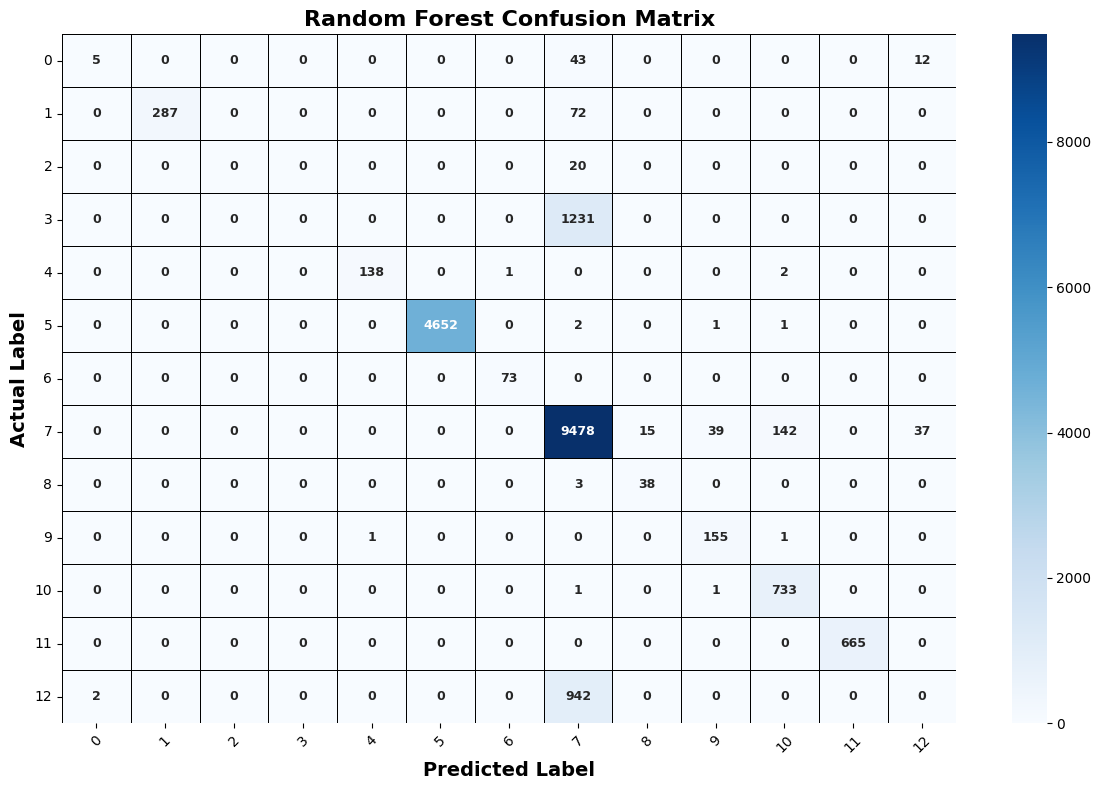

In [63]:
cm_rf = confusion_matrix(y_m_test, y_pred_rf)
plt.figure(figsize=(12,8))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=True,
            annot_kws={"size":9, "weight":"bold"}, linewidths=0.5, linecolor="black")
plt.xlabel("Predicted Label", fontsize=14, weight="bold")
plt.ylabel("Actual Label", fontsize=14, weight="bold")
plt.title("Random Forest Confusion Matrix", fontsize=16, weight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\siva\AppData\Local\Temp\ipykernel_6768\1557553223.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


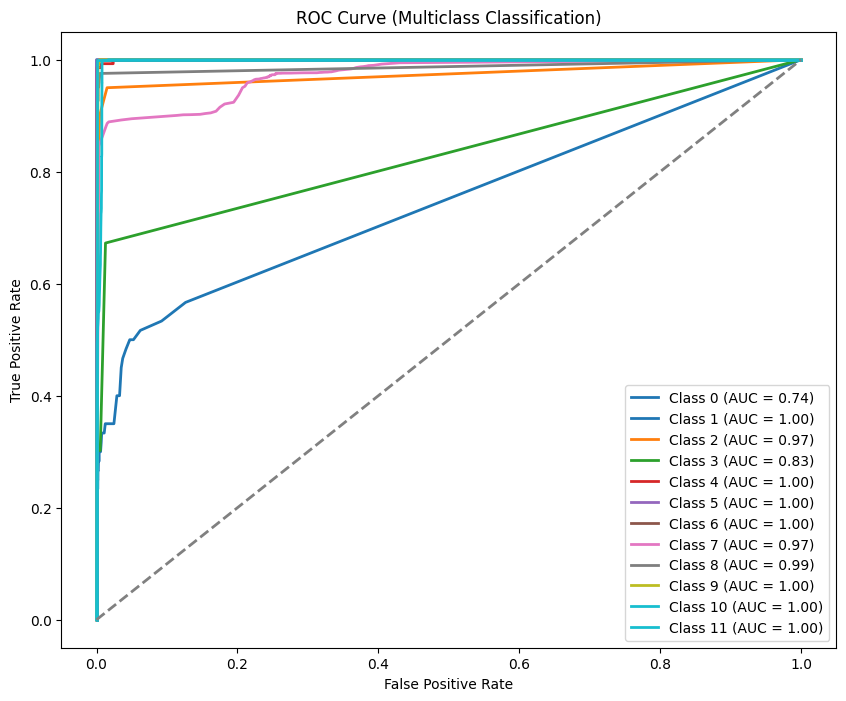

In [65]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Use model classes to avoid mismatch
classes = rf_m.classes_
y_test_bin = label_binarize(y_m_test, classes=classes)
n_classes = len(classes)-1

# Predict probabilities
y_prob = rf_m.predict_proba(X_m_test)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()


fpr[11], tpr[11], _ = roc_curve(y_test_bin[:, 11], y_prob[:, 11])
roc_auc[11] = auc(fpr[11], tpr[11])


for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10,8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, color=colors(i),
             label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass Classification)")
plt.legend(loc="lower right")
plt.show()


C:\Users\siva\AppData\Local\Temp\ipykernel_6768\2103292812.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(model_scores, labels=model_names, patch_artist=True)


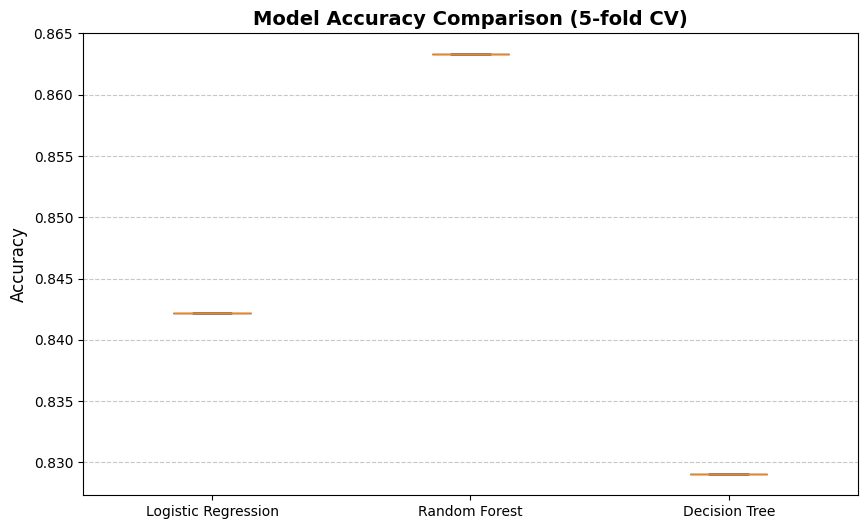

In [66]:

# Collect accuracy scores
model_scores = [
    [accuracy_lr_test],    # Logistic Regression accuracy
    [accuracy_rf_test],    # Random Forest accuracy
    [accuracy_dt_test]     # Decision Tree accuracy
]
model_names = ["Logistic Regression","Random Forest","Decision Tree"]


# Plot Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(model_scores, labels=model_names, patch_artist=True)
plt.title("Model Accuracy Comparison (5-fold CV)", fontsize=14, weight="bold")
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


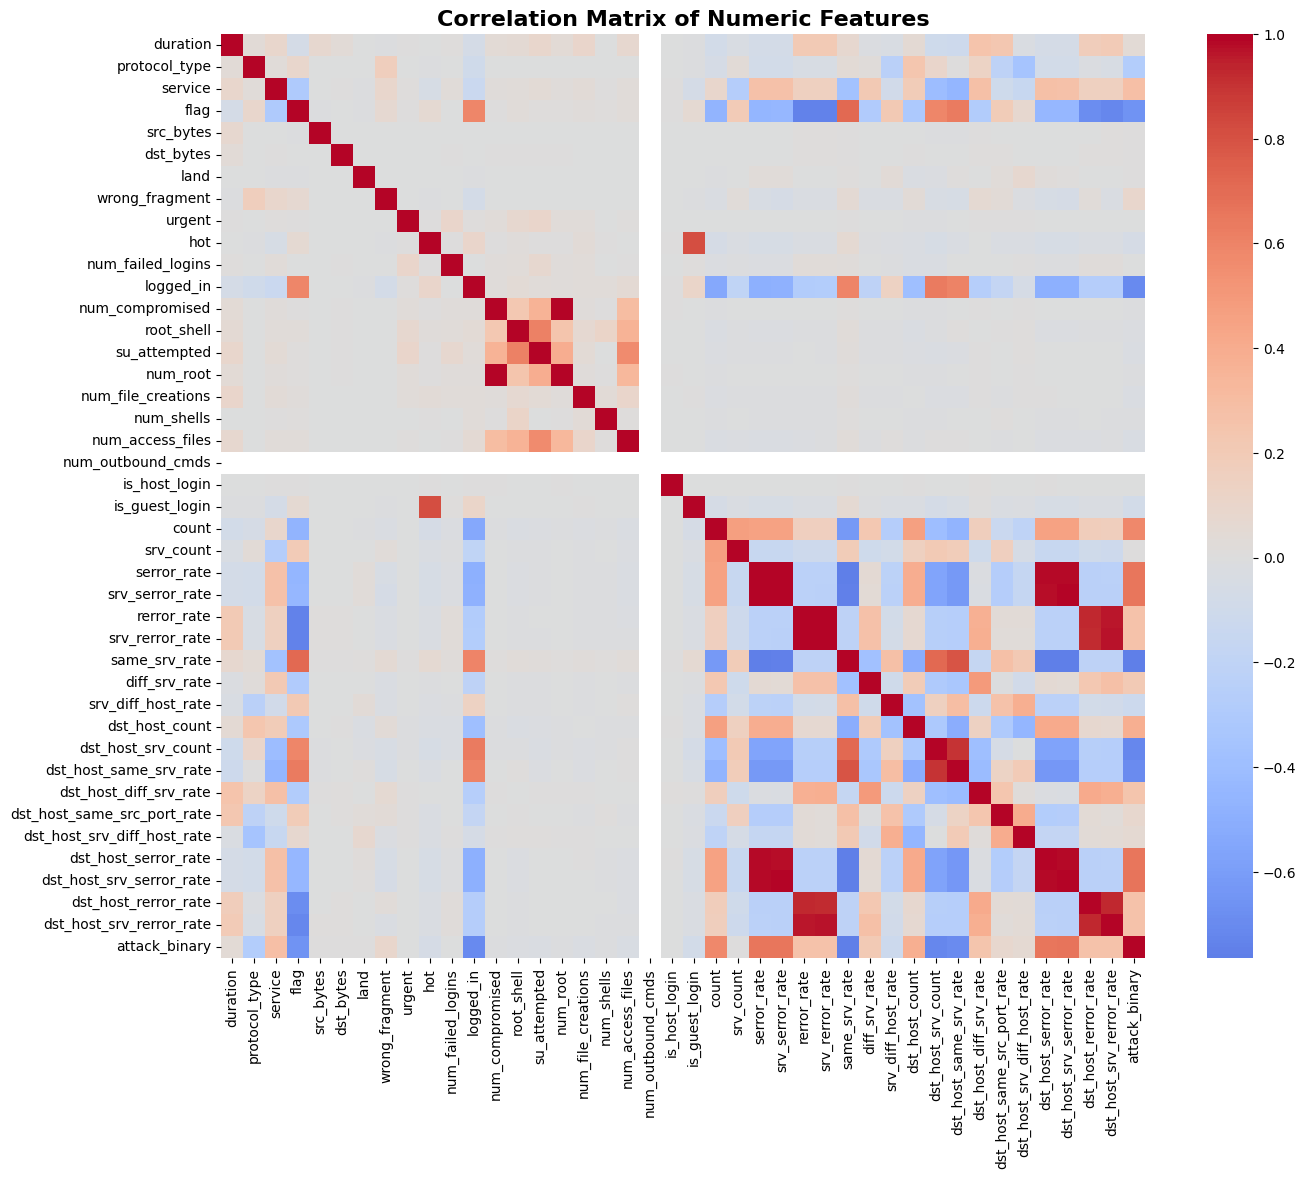

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = train_df[numeric_cols].corr()

# Plot
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=False,      # True = show correlation values
    cmap="coolwarm",
    center=0,
    cbar=True,
    square=True
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16, weight="bold")
plt.show()


In [71]:
# Save trained models
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save Logistic Regression model (from binary classification)
joblib.dump(lr, "./models/Logistic_Regression.pkl")

# Save Random Forest model (from binary classification)
joblib.dump(rf, "./models/Random_Forest.pkl")

# Save Decision Tree model (from binary classification)
joblib.dump(dt_res, "./models/Decision_Tree.pkl")

# Save Logistic Regression model (from multiclass classification)
joblib.dump(lr_m, "./models/Logistic_Regression_Multiclass.pkl")

# Save Random Forest model (from multiclass classification)
joblib.dump(rf_m, "./models/Random_Forest_Multiclass.pkl")

# Save Decision Tree model (from multiclass classification)
joblib.dump(dt_res_m, "./models/Decision_Tree_Multiclass.pkl")
print("Models saved successfully!")
print("Saved models:")
print("- Logistic_Regression.pkl")
print("- Random_Forest.pkl") 
print("- Decision_Tree.pkl")
print("- Logistic_Regression_Multiclass.pkl")
print("- Random_Forest_Multiclass.pkl") 
print("- Decision_Tree_Multiclass.pkl")


Models saved successfully!
Saved models:
- Logistic_Regression.pkl
- Random_Forest.pkl
- Decision_Tree.pkl
- Logistic_Regression_Multiclass.pkl
- Random_Forest_Multiclass.pkl
- Decision_Tree_Multiclass.pkl
